In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

PROJECT_DIR = "/content/drive/MyDrive/2026 Deep Learning Bitcoin Fraud Detection"
PROCESSED_PATH = f"{PROJECT_DIR}/Dataset/processed/transaction_graph_v1.pt"

# Stay in /content to avoid import issues if Drive hiccups
%cd /content

# Quick check the file is visible
!ls -lah "{PROJECT_DIR}/Dataset/processed"


Mounted at /content/drive
/content
total 626M
-rw------- 1 root root 1.3K Feb 12 16:40 pre_filter.pt
-rw------- 1 root root 1.3K Feb 12 16:40 pre_transform.pt
-rw------- 1 root root 491M Feb 10 22:56 transaction_actor_graph_v1.pt
-rw------- 1 root root 135M Feb 12 16:40 transaction_graph_v1.pt


In [2]:
!pip -q uninstall -y torch-geometric torch_geometric transformers safetensors || true
!pip -q install pandas numpy matplotlib scikit-learn tqdm
!pip -q install "torch-geometric==2.5.3"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 32.9 MB/s eta 0:00:00


In [3]:
import torch

# Load the saved object (your file is a tuple)
elliptic_tuple = torch.load(PROCESSED_PATH, weights_only=False, map_location="cpu")

type(elliptic_tuple), len(elliptic_tuple)


(tuple, 3)

In [4]:
data_dict, slices, data_cls = elliptic_tuple  # slices is None in your case

x = data_dict["x"]
edge_index = data_dict["edge_index"]
y = data_dict["y"]
train_mask = data_dict["train_mask"]
val_mask = data_dict["val_mask"]
test_mask = data_dict["test_mask"]

print("x:", x.shape, x.dtype)
print("edge_index:", edge_index.shape, edge_index.dtype)
print("y:", y.shape, y.dtype)
print("mask sums:", int(train_mask.sum()), int(val_mask.sum()), int(test_mask.sum()))


x: torch.Size([203769, 166]) torch.float32
edge_index: torch.Size([2, 234355]) torch.int64
y: torch.Size([203769]) torch.int64
mask sums: 163015 20376 20378


**Elliptic transaction graph:**

We load a preprocessed version of the Elliptic dataset as tensors:

x ∈ R^{N×166} node features, where x[:,0] encodes time step (1..49) in this processed artifact.

edge_index ∈ Z^{2×E} directed edges representing payment flow.

y ∈ {0,1,2}^N labels:

0 = licit, 1 = illicit, 2 = unknown/unlabeled (dominant).

train/val/test masks were predefined by the preprocessing pipeline (I did not modify them in this EDA).

**Key EDA goals:**

quantify label availability and drift across time

characterize graph topology and connectivity

measure graph–label association (homophily/mixing)

assess feature quality and potential leakage (time-step column)

In [5]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LICIT, ILLICIT, UNKNOWN = 0, 1, 2

N = x.size(0)
E = edge_index.size(1)

print("N nodes:", N)
print("E edges:", E)
print("x:", tuple(x.shape), x.dtype)
print("y:", tuple(y.shape), y.dtype)

uniq, cnt = torch.unique(y, return_counts=True)
print("Label counts:", dict(zip(uniq.tolist(), cnt.tolist())))

t = x[:, 0].long()
print("time step from x[:,0] min/max:", int(t.min()), int(t.max()))


N nodes: 203769
E edges: 234355
x: (203769, 166) torch.float32
y: (203769,) torch.int64
Label counts: {0: 42019, 1: 4545, 2: 157205}
time step from x[:,0] min/max: 1 49


**Split diagnostics:**

We report labeled counts and illicit rates within each provided mask. Note that we shoud exclude unknown labels (y=2) from any supervised evaluation.

The observed illicit base rate differs substantially across splits, which is consistent with temporal drift and/or different time-step coverage in each split.

We will later verify the time-step ranges per split and whether time steps overlap across train/val/test

In [6]:
train_mask = train_mask.bool()
val_mask   = val_mask.bool()
test_mask  = test_mask.bool()

labeled = (y != UNKNOWN)

def split_stats(name, m):
    m = m & labeled
    yy = y[m]
    n = int(m.sum())
    n_il = int((yy == ILLICIT).sum())
    n_li = int((yy == LICIT).sum())
    rate = n_il / max(1, (n_il + n_li))
    ts = torch.unique(t[m])
    print(f"{name}: labeled={n:,} illicit={n_il:,} licit={n_li:,} illicit_rate={rate:.4f} | t={int(ts.min())}..{int(ts.max())} (n_ts={len(ts)})")

print("Overall labeled:", int(labeled.sum()),
      "| illicit:", int((y==ILLICIT).sum()),
      "| licit:", int((y==LICIT).sum()))

split_stats("TRAIN", train_mask)
split_stats("VAL  ", val_mask)
split_stats("TEST ", test_mask)


Overall labeled: 46564 | illicit: 4545 | licit: 42019
TRAIN: labeled=36,930 illicit=4,040 licit=32,890 illicit_rate=0.1094 | t=1..41 (n_ts=41)
VAL  : labeled=5,707 illicit=380 licit=5,327 illicit_rate=0.0666 | t=41..44 (n_ts=4)
TEST : labeled=3,927 illicit=125 licit=3,802 illicit_rate=0.0318 | t=44..49 (n_ts=6)


We want to check if there is temporal drift in the labels. Elliptic provides discrete time steps (1..49). In this processed representation, time step is stored in x[:,0].

We are going to plot:

labeled transaction counts per time step

illicit rate among labeled transactions per time step

This is useful for:

understanding class imbalance over time

anticipating distribution shift in time-forward evaluation

,licit(0),illicit(1),total_labeled,illicit_rate
t,,,,
1,2130,17,2147,0.007918
2,1099,18,1117,0.016115
3,1268,11,1279,0.008600
4,1410,30,1440,0.020833
5,1874,8,1882,0.004251
6,480,5,485,0.010309
7,1101,102,1203,0.084788
8,1098,67,1165,0.057511
9,530,248,778,0.318766


,licit(0),illicit(1),total_labeled,illicit_rate
t,,,,
40,1099,112,1211,0.092486
41,1016,116,1132,0.102473
42,1915,239,2154,0.110956
43,1346,24,1370,0.017518
44,1567,24,1591,0.015085
45,1216,5,1221,0.004095
46,710,2,712,0.002809
47,824,22,846,0.026005
48,435,36,471,0.076433


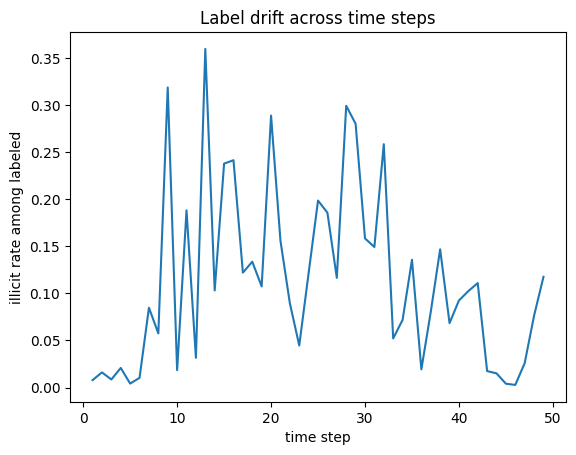

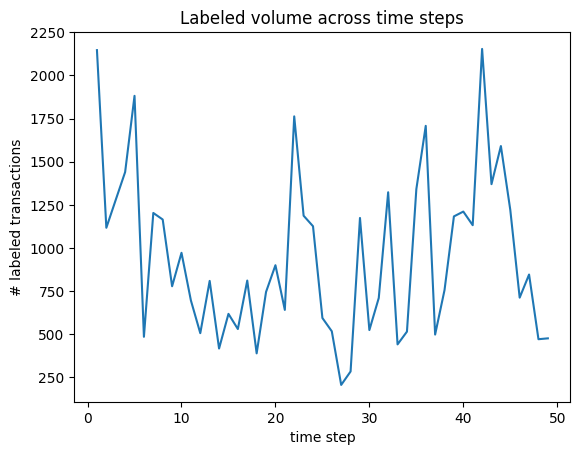

In [7]:
t_np = t.cpu().numpy()
y_np = y.cpu().numpy()

df_lab = pd.DataFrame({"t": t_np, "y": y_np})
df_lab = df_lab[df_lab["y"] != UNKNOWN].copy()
df_lab["count"] = 1

pivot = df_lab.pivot_table(index="t", columns="y", values="count", aggfunc="sum", fill_value=0)
for col in [LICIT, ILLICIT]:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[[LICIT, ILLICIT]]
pivot.columns = ["licit(0)", "illicit(1)"]
pivot["total_labeled"] = pivot.sum(axis=1)
pivot["illicit_rate"] = pivot["illicit(1)"] / pivot["total_labeled"].clip(lower=1)

display(pivot.head(10))
display(pivot.tail(10))

plt.figure()
plt.plot(pivot.index, pivot["illicit_rate"])
plt.xlabel("time step")
plt.ylabel("illicit rate among labeled")
plt.title("Label drift across time steps")
plt.show()

plt.figure()
plt.plot(pivot.index, pivot["total_labeled"])
plt.xlabel("time step")
plt.ylabel("# labeled transactions")
plt.title("Labeled volume across time steps")
plt.show()


**Time-step coverage by split:**

Which time steps are included in each pipeline-defined split?

If train/val/test share time steps, I am not sure if this is inherently wrong or not, but it weakens the “strict time-forward” narrative. Perhaps we should discuss this with Lindsay

In [8]:
def time_steps(mask):
    return torch.unique(t[mask]).cpu().numpy()

ts_train = time_steps(train_mask)
ts_val   = time_steps(val_mask)
ts_test  = time_steps(test_mask)

print("TRAIN time steps:", ts_train.min(), "..", ts_train.max(), "| count:", len(ts_train))
print("VAL   time steps:", ts_val.min(),   "..", ts_val.max(),   "| count:", len(ts_val))
print("TEST  time steps:", ts_test.min(),  "..", ts_test.max(),  "| count:", len(ts_test))

# Overlap
over_train_val = np.intersect1d(ts_train, ts_val)
over_val_test  = np.intersect1d(ts_val, ts_test)
over_train_test= np.intersect1d(ts_train, ts_test)

print("Overlap TRAIN∩VAL:", over_train_val)
print("Overlap VAL∩TEST :", over_val_test)
print("Overlap TRAIN∩TEST:", over_train_test)


TRAIN time steps: 1 .. 41 | count: 41
VAL   time steps: 41 .. 44 | count: 4
TEST  time steps: 44 .. 49 | count: 6
Overlap TRAIN∩VAL: [41]
Overlap VAL∩TEST : [44]
Overlap TRAIN∩TEST: []


**Graph separation across time:**

The Elliptic transaction graph is known to have edges only within the same time step (no edges across time).

We verify this property: if true, the full dataset is effectively a union of 49 disconnected graphs (one per time step).


In [9]:
src = edge_index[0].cpu()
dst = edge_index[1].cpu()

cross = (t[src] != t[dst])
print("Edges crossing time steps:", int(cross.sum()), "out of", edge_index.size(1))


Edges crossing time steps: 0 out of 234355


**Graph size per time step:**

We compute nodes and edges per time step, and a rough average undirected degree 2E_t / N_t per time step.
This helps contextualize whether certain time steps are unusually sparse/dense.

,nodes,edges,avg_deg_undirected_approx
1,7880,9164,2.325888
2,4544,5241,2.306778
3,6621,8316,2.512007
4,5693,8180,2.873705
5,6803,8623,2.535058
6,4328,5242,2.422366
7,6048,7253,2.398479
8,4457,5186,2.327126
9,4996,5939,2.377502
10,6727,8588,2.553293


,nodes,edges,avg_deg_undirected_approx
40,4481,5246,2.341442
41,5342,6093,2.281168
42,7140,8493,2.378992
43,5063,5950,2.350385
44,4975,5551,2.231558
45,5598,6673,2.384066
46,3519,3866,2.197215
47,5121,5748,2.244874
48,2954,3284,2.223426
49,2454,2587,2.108394


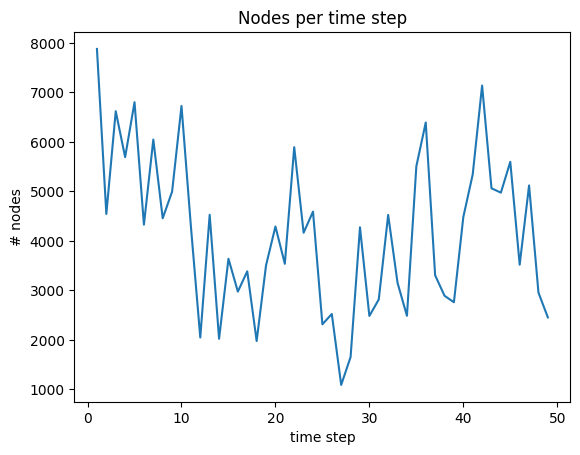

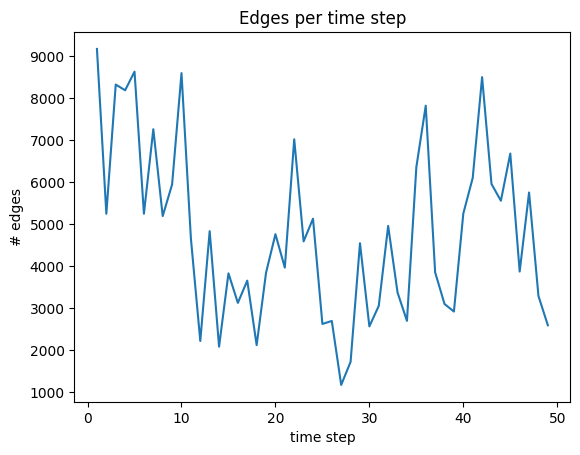

In [10]:
src_np = src.numpy()
t_src = t_np[src_np]  # time step per edge (same as dst)

nodes_per_t = pd.Series(t_np).value_counts().sort_index()
edges_per_t = pd.Series(t_src).value_counts().sort_index()

df_size = pd.DataFrame({"nodes": nodes_per_t, "edges": edges_per_t}).fillna(0).astype(int)
df_size["avg_deg_undirected_approx"] = (2 * df_size["edges"]) / df_size["nodes"].clip(lower=1)

display(df_size.head(10))
display(df_size.tail(10))

plt.figure()
plt.plot(df_size.index, df_size["nodes"])
plt.xlabel("time step"); plt.ylabel("# nodes"); plt.title("Nodes per time step"); plt.show()

plt.figure()
plt.plot(df_size.index, df_size["edges"])
plt.xlabel("time step"); plt.ylabel("# edges"); plt.title("Edges per time step"); plt.show()


**Degree distribution:**

We examine in-degree, out-degree, and total degree distributions. Transaction graphs are typically heavy-tailed (few high-degree nodes, many low-degree nodes).
We report percentiles and visualize histograms on linear and log scales.

out_deg percentiles: {0: 0.0, 50: 1.0, 90: 2.0, 95: 2.0, 99: 5.0, 99.9: 16.0, 100: 472.0}
in_deg  percentiles: {0: 0.0, 50: 1.0, 90: 1.0, 95: 2.0, 99: 9.0, 99.9: 59.0, 100: 284.0}
tot_deg percentiles: {0: 1.0, 50: 2.0, 90: 3.0, 95: 4.0, 99: 13.0, 99.9: 64.0, 100: 473.0}


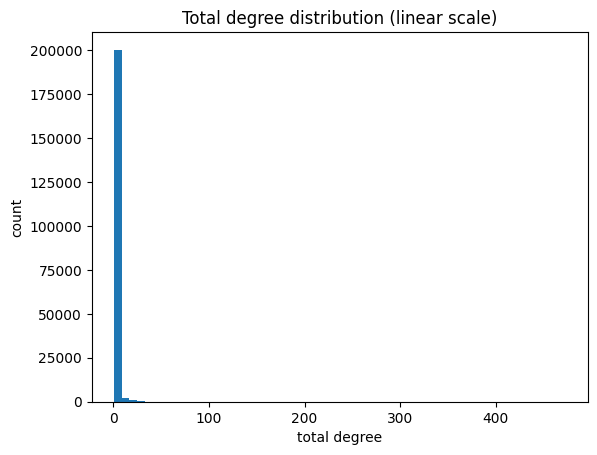

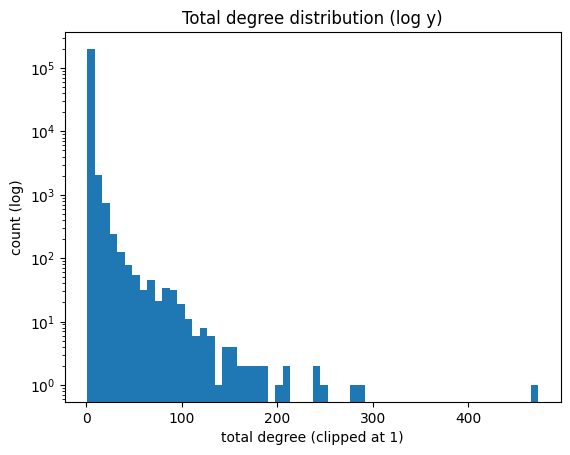

Fraction with out_deg=0: 0.1836589471411255
Fraction with in_deg=0 : 0.27149370120086963


In [11]:
import numpy as np
import matplotlib.pyplot as plt

N = x.size(0)
src_np = src.numpy()
dst_np = dst.numpy()

out_deg = np.bincount(src_np, minlength=N)
in_deg  = np.bincount(dst_np, minlength=N)
tot_deg = out_deg + in_deg

def pct(x, ps=[0, 50, 90, 95, 99, 99.9, 100]):
    return {p: float(np.percentile(x, p)) for p in ps}

print("out_deg percentiles:", pct(out_deg))
print("in_deg  percentiles:", pct(in_deg))
print("tot_deg percentiles:", pct(tot_deg))

plt.figure()
plt.hist(tot_deg, bins=60)
plt.xlabel("total degree"); plt.ylabel("count")
plt.title("Total degree distribution (linear scale)")
plt.show()

plt.figure()
plt.hist(np.clip(tot_deg, 1, None), bins=60, log=True)
plt.xlabel("total degree (clipped at 1)"); plt.ylabel("count (log)")
plt.title("Total degree distribution (log y)")
plt.show()

print("Fraction with out_deg=0:", float((out_deg == 0).mean()))
print("Fraction with in_deg=0 :", float((in_deg  == 0).mean()))


**Topology differs by label**

We compare degree statistics for licit vs illicit labeled nodes.
This matters because message passing can be less informative for nodes with very small neighborhoods, and because topology itself may correlate with illicit behavior patterns.

In [12]:
LICIT, ILLICIT, UNKNOWN = 0, 1, 2
y_np = y.cpu().numpy()

def summarize_deg(label_val, name):
    d = tot_deg[y_np == label_val]
    print(f"{name}: n={len(d):,} mean={d.mean():.2f} median={np.median(d):.2f} "
          f"p90={np.percentile(d,90):.1f} p95={np.percentile(d,95):.1f} "
          f"p99={np.percentile(d,99):.1f} max={d.max():.0f}")

summarize_deg(LICIT,   "Licit (0)")
summarize_deg(ILLICIT, "Illicit (1)")


Licit (0): n=42,019 mean=3.10 median=2.00 p90=4.0 p95=8.0 p99=28.0 max=473
Illicit (1): n=4,545 mean=2.01 median=1.00 p90=2.0 p95=3.0 p99=5.0 max=177


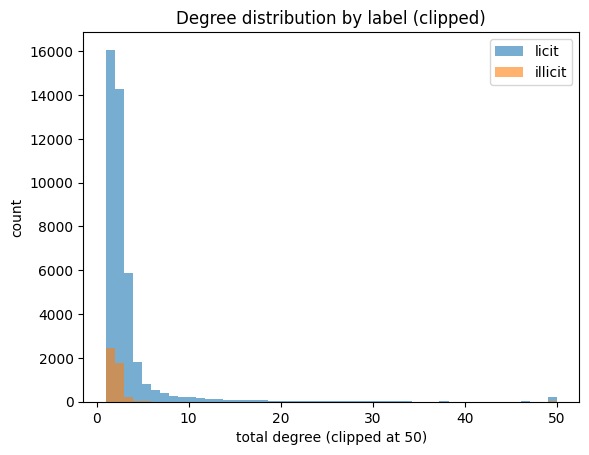

In [14]:
plt.figure()
plt.hist(np.clip(tot_deg[y_np==LICIT], 0, 50), bins=50, alpha=0.6, label="licit")
plt.hist(np.clip(tot_deg[y_np==ILLICIT], 0, 50), bins=50, alpha=0.6, label="illicit")
plt.xlabel("total degree (clipped at 50)")
plt.ylabel("count")
plt.title("Degree distribution by label (clipped)")
plt.legend()
plt.show()


**Label mixing along edges**

We compute mixing matrices over directed edges:

A 3×3 matrix over {licit, illicit, unknown} to show how much of the graph touches unknown nodes.

A 2×2 labeled-only matrix to measure how strongly licit/illicit cluster when labels exist.

We also report:

P(same-label edge) on labeled-only edges

P(dst=illicit | src=illicit) vs P(dst=illicit | src=licit) as a simple homophily indicator

In [15]:
import pandas as pd
import numpy as np

LICIT, ILLICIT, UNKNOWN = 0, 1, 2
ys = y_np[src_np]
yd = y_np[dst_np]

# 3x3 mixing over {0,1,2}
M3 = np.zeros((3,3), dtype=int)
for a,b in zip(ys, yd):
    M3[a,b] += 1

mix3 = pd.DataFrame(
    M3,
    index=["src_licit(0)","src_illicit(1)","src_unknown(2)"],
    columns=["dst_licit(0)","dst_illicit(1)","dst_unknown(2)"]
)
display(mix3)

# 2x2 labeled-only mixing
mask_ll = (ys != UNKNOWN) & (yd != UNKNOWN)
ys2 = ys[mask_ll]
yd2 = yd[mask_ll]

M2 = np.zeros((2,2), dtype=int)
for a,b in zip(ys2, yd2):
    M2[a,b] += 1

mix2 = pd.DataFrame(
    M2,
    index=["src_licit(0)","src_illicit(1)"],
    columns=["dst_licit(0)","dst_illicit(1)"]
)
display(mix2)

p_same = (M2[0,0] + M2[1,1]) / max(1, M2.sum())
p_il_to_il = M2[1,1] / max(1, M2[1].sum())
p_li_to_il = M2[0,1] / max(1, M2[0].sum())

print("Edges with labeled endpoints:", int(mask_ll.sum()), "out of", len(src_np))
print(f"P(edge same-label) = {p_same:.4f}")
print(f"P(dst=illicit | src=illicit) = {p_il_to_il:.4f}")
print(f"P(dst=illicit | src=licit)   = {p_li_to_il:.4f}")


,dst_licit(0),dst_illicit(1),dst_unknown(2)
src_licit(0),33930,781,15116
src_illicit(1),915,998,1458
src_unknown(2),45386,3993,131778


,dst_licit(0),dst_illicit(1)
src_licit(0),33930,781
src_illicit(1),915,998


Edges with labeled endpoints: 36624 out of 234355
P(edge same-label) = 0.9537
P(dst=illicit | src=illicit) = 0.5217
P(dst=illicit | src=licit)   = 0.0225


**How much labeled neighborhood information exists?**

Most nodes are unlabeled (unknown). Even among labeled nodes, some have few or no labeled neighbors.

We compute for each node:

how many labeled neighbors it has (incoming and outgoing, based on labeled endpoints)

the oracle fraction of labeled neighbors that are illicit (uses true neighbor labels; diagnostic only)

This helps answer:

Is graph label signal present? (yes/no)

Is it widely available or sparse? (how many nodes have labeled neighbors)

,y,out_labeled_n,in_labeled_n,frac_out_illicit_oracle,frac_in_illicit_oracle
0,0,1,61,0.0,0.016393
1,0,1,22,0.0,0.000000
2,0,2,0,0.0,0.000000
3,0,1,1,0.0,0.000000
4,0,1,1,0.0,0.000000


frac_out_illicit_oracle: licit mean=0.0126 median=0.0000 | illicit mean=0.2036 median=0.0000
frac_in_illicit_oracle: licit mean=0.0034 median=0.0000 | illicit mean=0.1988 median=0.0000
Labeled nodes with >=1 labeled OUT-neighbor: 27143 out of 46564
Labeled nodes with >=1 labeled IN-neighbor : 21441 out of 46564


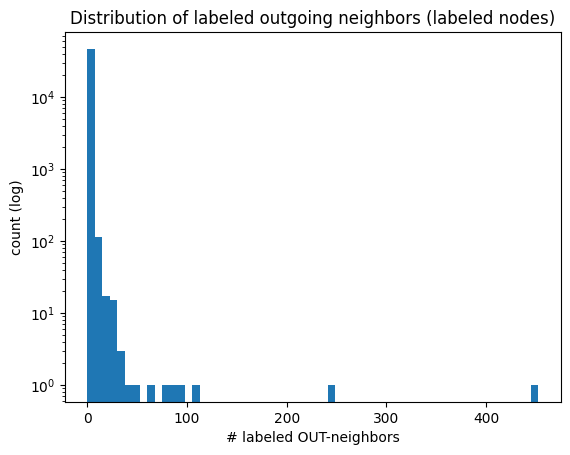

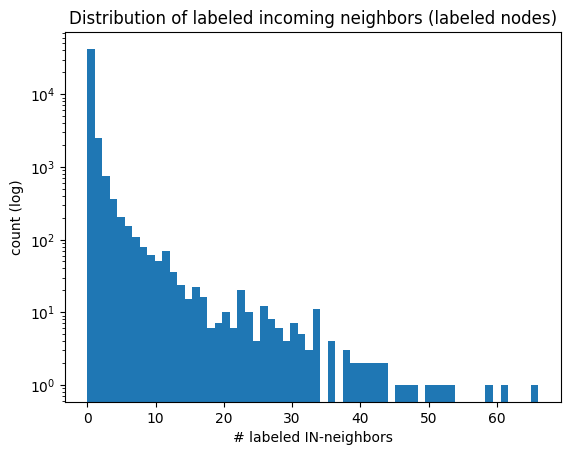

In [16]:
LICIT, ILLICIT, UNKNOWN = 0, 1, 2

is_lab = (y_np != UNKNOWN)
is_il  = (y_np == ILLICIT)

out_lab = np.zeros(N, dtype=np.int32)
out_il  = np.zeros(N, dtype=np.int32)

mask_dst_lab = is_lab[dst_np]
np.add.at(out_lab, src_np[mask_dst_lab], 1)
np.add.at(out_il,  src_np[mask_dst_lab & is_il[dst_np]], 1)

in_lab = np.zeros(N, dtype=np.int32)
in_il  = np.zeros(N, dtype=np.int32)

mask_src_lab = is_lab[src_np]
np.add.at(in_lab, dst_np[mask_src_lab], 1)
np.add.at(in_il,  dst_np[mask_src_lab & is_il[src_np]], 1)

frac_out_oracle = out_il / np.clip(out_lab, 1, None)
frac_in_oracle  = in_il  / np.clip(in_lab,  1, None)

idx_lab = np.where(is_lab)[0]
summ = pd.DataFrame({
    "y": y_np[idx_lab],
    "out_labeled_n": out_lab[idx_lab],
    "in_labeled_n": in_lab[idx_lab],
    "frac_out_illicit_oracle": frac_out_oracle[idx_lab],
    "frac_in_illicit_oracle": frac_in_oracle[idx_lab],
})
display(summ.head())

def by_class(col):
    a0 = summ.loc[summ["y"]==LICIT, col].values
    a1 = summ.loc[summ["y"]==ILLICIT, col].values
    print(f"{col}: licit mean={a0.mean():.4f} median={np.median(a0):.4f} | illicit mean={a1.mean():.4f} median={np.median(a1):.4f}")

by_class("frac_out_illicit_oracle")
by_class("frac_in_illicit_oracle")

print("Labeled nodes with >=1 labeled OUT-neighbor:", int((summ["out_labeled_n"]>0).sum()), "out of", len(summ))
print("Labeled nodes with >=1 labeled IN-neighbor :", int((summ["in_labeled_n"]>0).sum()), "out of", len(summ))

plt.figure()
plt.hist(summ["out_labeled_n"], bins=60, log=True)
plt.xlabel("# labeled OUT-neighbors"); plt.ylabel("count (log)")
plt.title("Distribution of labeled outgoing neighbors (labeled nodes)")
plt.show()

plt.figure()
plt.hist(summ["in_labeled_n"], bins=60, log=True)
plt.xlabel("# labeled IN-neighbors"); plt.ylabel("count (log)")
plt.title("Distribution of labeled incoming neighbors (labeled nodes)")
plt.show()


**Feature quality & potential leakage**

We run basic feature QC:

check for NaNs / inf

detect near-constant features (low variance)

compute correlation with time step to highlight drift and why time (x[:,0]) should be excluded from modeling

In [17]:
X = x.cpu().numpy()
t_np = X[:, 0]
X_feat = X[:, 1:]  # exclude time step

print("Any NaNs in X_feat?", np.isnan(X_feat).any())
print("Any inf in X_feat?", np.isinf(X_feat).any())

var = X_feat.var(axis=0)
near_const = np.where(var < 1e-8)[0]
print("Near-constant features:", len(near_const))
if len(near_const) > 0:
    print("Indices (first 30):", near_const[:30].tolist())

# Correlation with time step (Pearson)
t_z = (t_np - t_np.mean()) / (t_np.std() + 1e-12)
X_z = (X_feat - X_feat.mean(axis=0)) / (X_feat.std(axis=0) + 1e-12)
corr_time = (X_z * t_z[:, None]).mean(axis=0)

top = np.argsort(np.abs(corr_time))[::-1][:15]
df_corr = pd.DataFrame({"feat_idx": top, "corr_with_time": corr_time[top], "abs_corr": np.abs(corr_time[top])})
display(df_corr)


Any NaNs in X_feat? False
Any inf in X_feat? False
Near-constant features: 0


,feat_idx,corr_with_time,abs_corr
0,100,0.994448,0.994448
1,102,0.992579,0.992579
2,99,0.982430,0.982430
3,135,0.911859,0.911859
4,138,0.890583,0.890583
5,136,0.788108,0.788108
6,114,0.580025,0.580025
7,2,0.573155,0.573155
8,150,0.571132,0.571132
9,111,0.562550,0.562550


**Interim takeaways (EDA)**

The transaction graph is split into 49 disconnected time-step graphs (no cross-time edges).

Labels are sparse: most nodes are unknown, and the illicit base rate varies strongly by time/split.

Topology differs by label: illicit nodes tend to have smaller degree than licit nodes.

Despite sparse labels, labeled–labeled edges show strong clustering (homophily), suggesting graph structure can provide predictive signal.

Several features show correlation with time step; we should treat time as a potential leakage/shortcut feature in modeling.

**Open questions to resolve**

Are the provided train/val/test masks acceptable for “time-forward” evaluation, or should we use strict non-overlapping time windows?

For modeling later: treat edges as directed or undirected?

How to handle the large unknown portion?